# EDA: Can interaction times characterize relationship patterns?

This notebook asks whether repeated Bluetooth ties have recognizable temporal patterns—for example, weekday class-hour contact versus evening and weekend contact.

> The dataset does not contain labels such as *classmate*, *roommate*, or *close friend*. The groups below are therefore **temporal behavior archetypes**, not confirmed relationship types.

In [2]:
%matplotlib inline
from pathlib import Path
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

module_name = "physical_digital_eda.py"
candidates = []
for base in [Path.cwd(), *Path.cwd().parents]:
    candidates.extend([
        base,
        base / "notebooks",
        base / "FinalProject" / "notebooks",
        base / "26-the-deep-learners-analysis" / "FinalProject" / "notebooks",
    ])
module_dir = next((path for path in candidates if (path / module_name).exists()), None)
if module_dir is None:
    raise FileNotFoundError(
        f"Could not find {module_name}. Current working directory: {Path.cwd()}"
    )
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

from physical_digital_eda import (
    load_and_prepare,
    plot_class_vs_after_hours,
    plot_schedule_by_digital_relationship,
    plot_temporal_cluster_diagnostics,
    plot_temporal_cluster_profiles,
)

sns.set_theme(style="whitegrid", context="notebook")
print(f"Loaded visualization helpers from: {module_dir}")

Loaded visualization helpers from: c:\Users\Rmcas\OneDrive\Desktop\COSMOS\26-the-deep-learners-analysis\FinalProject\notebooks


## Prepare temporal dyad features

The analysis uses the same repeated physical-tie definition as the primary EDA: `RSSI >= -80`, at least 12 close intervals, and at least 3 distinct days.

In [3]:
data = load_and_prepare()
temporal_columns = [
    "close_intervals",
    "close_days",
    "close_class_hour_intervals",
    "close_late_evening_intervals",
    "close_weekend_intervals",
    "class_hour_share",
    "after_hours_share",
    "temporal_entropy",
    "longest_session_intervals",
]
physical_dyads = data.dyads.loc[data.dyads["physical_tie"] == 1]
print(f"Repeated physical ties analyzed: {len(physical_dyads):,}")
display(physical_dyads[temporal_columns].describe().round(3))

Repeated physical ties analyzed: 6,159


,close_intervals,close_days,close_class_hour_intervals,close_late_evening_intervals,close_weekend_intervals,class_hour_share,after_hours_share,temporal_entropy,longest_session_intervals
count,6159.000,6159.000,6159.000,6159.000,6159.000,6159.000,6159.000,6159.000,6159.000
mean,98.749,6.508,32.262,6.041,10.484,0.396,0.158,0.525,12.161
std,218.406,3.953,47.616,29.925,60.659,0.257,0.307,0.159,14.229
min,12.000,3.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
25%,24.000,4.000,7.000,0.000,0.000,0.195,0.000,0.417,5.000
50%,46.000,5.000,17.000,0.000,0.000,0.407,0.000,0.526,8.000
75%,95.000,8.000,38.000,0.000,0.000,0.565,0.102,0.633,14.000
max,4862.000,28.000,606.000,615.000,1584.000,1.000,1.000,0.997,210.000


## 1. Class-hour versus after-hours contact

- **Class hours:** weekdays from 10 a.m. through 1:59 p.m.
- **After hours:** evenings, overnight periods, or weekends.

The lower-right region contains class-hour-concentrated pairs; the upper-left contains after-hours-concentrated pairs; the upper-right contains pairs active across both periods.

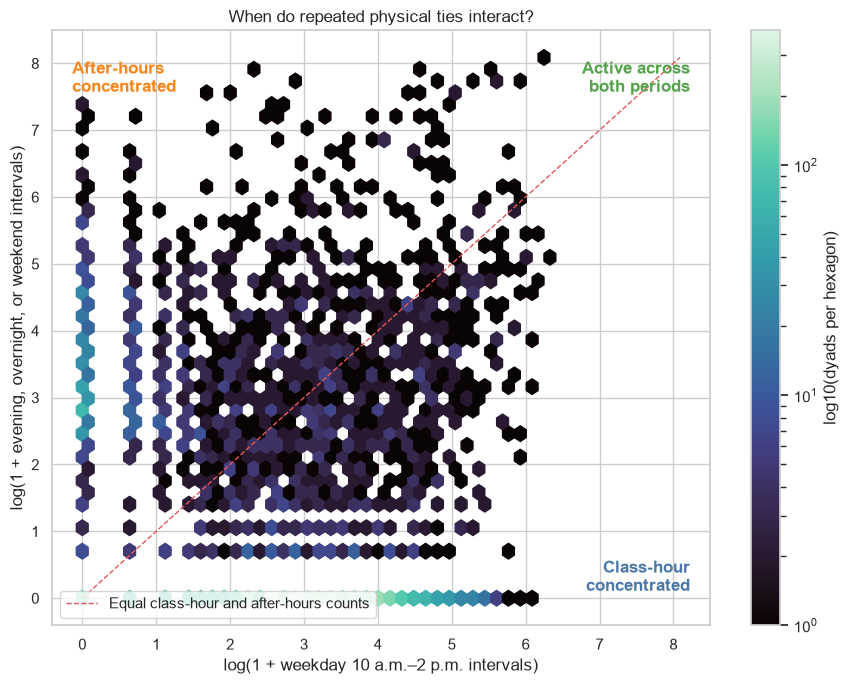

In [4]:
figure = plot_class_vs_after_hours(data)
figure.show()

## 2. Do temporal patterns align with digital relationships?

Calls, SMS, and Facebook do not prove relationship type, but they provide useful external context. If after-hours contact is socially meaningful, it should be more common among digitally connected pairs.

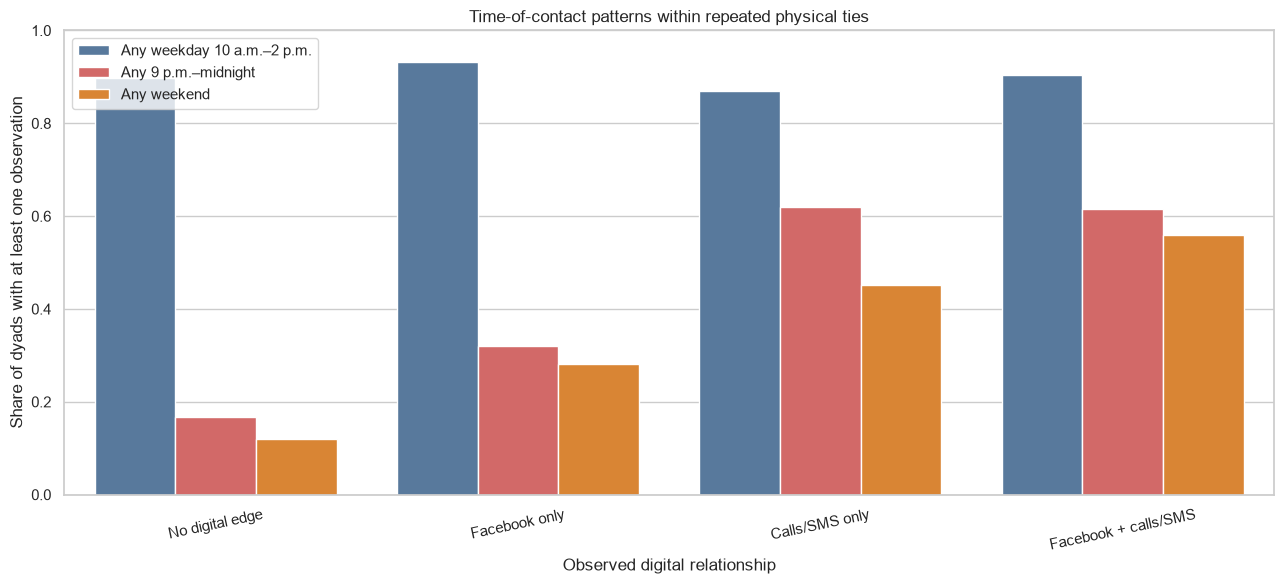

In [5]:
figure = plot_schedule_by_digital_relationship(data)
figure.show()

## 3. Are there naturally distinct temporal groups?

The silhouette score measures cluster separation. A higher value means the proposed groups are more distinct. This helps prevent us from inventing categories when the behavior is actually continuous.

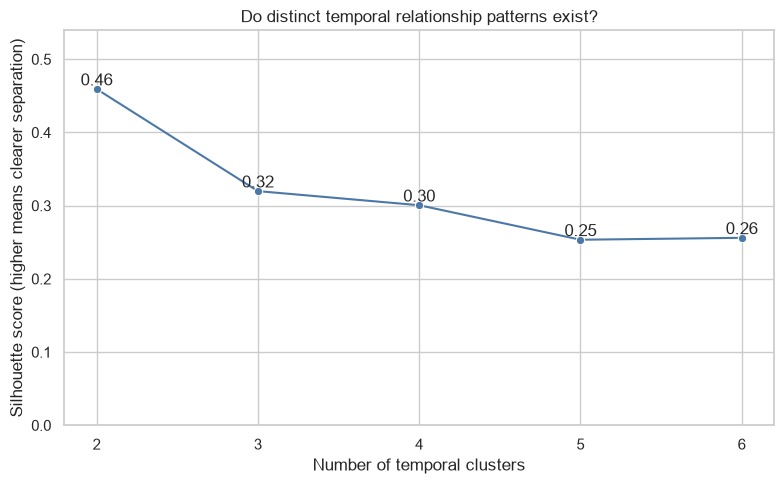

In [6]:
figure = plot_temporal_cluster_diagnostics(data)
figure.show()

## 4. Four descriptive temporal archetypes

Two clusters give the cleanest statistical separation. Four clusters are shown for richer interpretation, but they should be treated as approximate archetypes. Each heatmap shows the mean within-pair activity share by weekday and hour.

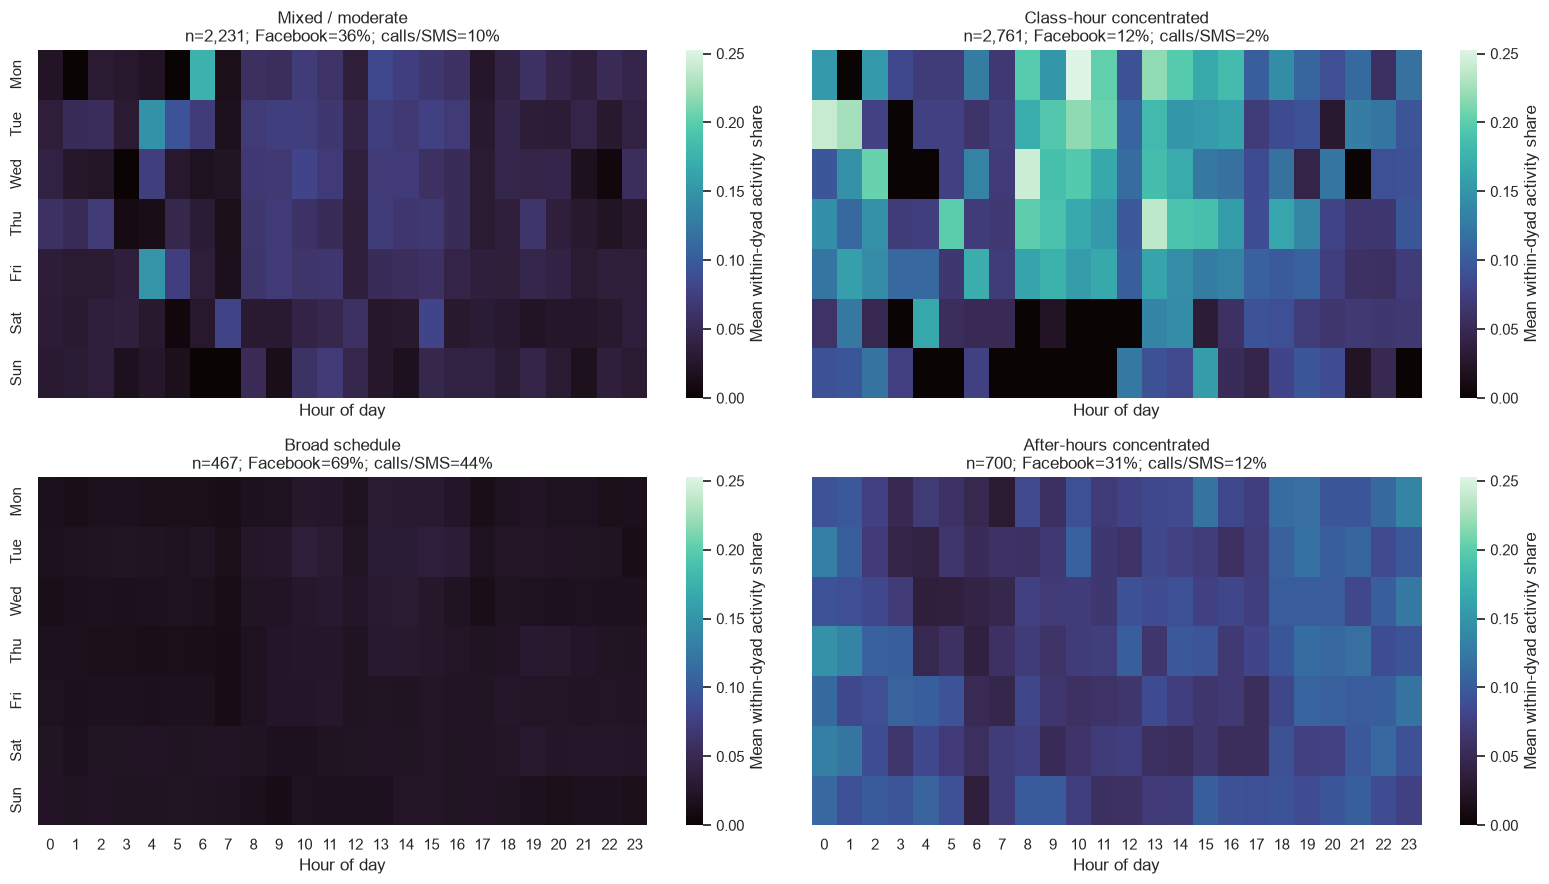

,dyads,facebook_rate,direct_communication_rate,median_close_intervals,median_close_days,median_class_hour_share,median_after_hours_share
temporal_archetype,,,,,,,
Mixed / moderate,2231,0.359,0.098,92.0,8.0,0.455,0.000
Class-hour concentrated,2761,0.120,0.015,25.0,4.0,0.481,0.000
Broad schedule,467,0.692,0.443,239.0,12.0,0.115,0.630
After-hours concentrated,700,0.313,0.120,27.0,4.0,0.000,0.889


In [7]:
cluster_figure, cluster_summary = plot_temporal_cluster_profiles(data, n_clusters=4)
cluster_figure.show()
display(cluster_summary.round(3))

## Interpretation

The initial EDA supports the idea that timestamps contain relationship information:

- Most repeated ties appear during weekday class hours.
- Late-evening and weekend contact is substantially more common among pairs with calls, SMS, or Facebook connections.
- The broad-schedule archetype has the strongest overlap with Facebook and direct communication.
- Class-hour-concentrated ties have much lower digital overlap and are plausible candidates for shared-course or shared-campus contact.

However, these patterns cannot prove that a pair consists of classmates, roommates, or close friends. A defensible project question is:

> **Can the timing, frequency, and duration of Bluetooth proximity distinguish temporal interaction archetypes, and how do those archetypes align with digital social ties?**